# **Multi-Building Design Update of CLT buildings**

This Jupyter Notebook demonstrates how to use the joint **Multi-Model Update** with the example of two, previously trained models of two Tall Timber Buildings: the Yoker and Palisaden buildings (see the notebook on Hybrid Digital Twinning of the Yoker Building [here](https://buildchain.ilab.sztaki.hu/notebooks/1_hybrid_digital_twinning/hybrid_Yoker.html)).

The main objective of the Multi-Building Updating is to calibrate uncertain parameters of simulation models across multiple buildings or experimental setups using shared measurement data. This ensemble-based calibration improves generalizability and robustness compared to single-structure updates.


In [1]:
import pickle
import pandas as pd
import digital_twinning as dt

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Load models

In this example we simply load two previusly trained hybrid models of the two system. The chosen parameters of the models were the following:

- Yoker: elastic moduli of the CLT panels in the three major strength directions ($e_{1}$, $e_{2}$, $e_{3}$), two in-plane shear moduli ($g_{1}$, $g_{2}$) and the distributed mass ($q$).
- Palisaden: scaling factor for the vertical elastic moduli of the CLT walls ($γ_{e_{1}}$), scaling factor for the in-plane shear stiffness of the walls ($γ_{G_{12}}$), additional scaling factor used for the external walls to  account for the increased  shear stiffness of these walls due to the facade ($γ_{G_{12,ext}}$), stiffness parameter of the foundation beneath the ground floor ($k_{spring}$) and a scaling factor of the initially estimated total mass of the building ($γ_{ρ}$)

The models are connected through the **$e_{1}$** and $γ_{e_{1}}$ parameters

In [2]:
#Load measurement data
z_yoker = pd.read_csv('../data/YB_data/z_m_df.csv')
z_palisaden = pd.read_csv('../data/PS_data/z_m_df.csv')

#Load standard deviation of the measurement error
sigma_yoker = pd.read_csv('../data/YB_data/sigma.csv')
sigma_palisaden = pd.read_csv('../data/PS_data/sigma.csv')

#Load surrogate models
with open('../data/YB_data/Yoker_model.sm', 'rb') as file:
    Yoker_model = pickle.load(file)
with open('../data/PS_data/Palisaden_model.sm', 'rb') as file:
    Palisaden_model = pickle.load(file)

# Update

In [4]:
#Define joint parameters
joint_parameters = {'joint_e1_COEF_VERT': ['e1', 'COEF_VERT']}

#Define the joint manager
j = dt.JointManager([Yoker_model, Palisaden_model], joint_parameters)
print(j.Q.variables)

{'joint_e1_COEF_VERT': U(-1, 1), 'e2': U(-1, 1), 'e3': U(-1, 1), 'g1': U(-1, 1), 'g2': U(-1, 1), 'q': U(-1, 1), 'COEF_G': U(-1, 1), 'FACADE': U(-1, 1), 'FOUNDATION': U(-1, 1), 'WEIGHT': U(-1, 1)}


In [5]:
nwalkers=32
niter=200
nburn=1000


j.update([z_yoker, z_palisaden], [sigma_yoker, sigma_palisaden], nwalkers=nwalkers, niter=niter, nburn=nburn)

MCMC creating
Burning period


100%|██████████| 1000/1000 [02:56<00:00,  5.67it/s]


MCMC running


100%|██████████| 200/200 [00:37<00:00,  5.37it/s]

--- 213.98490929603577 seconds ---


# Results

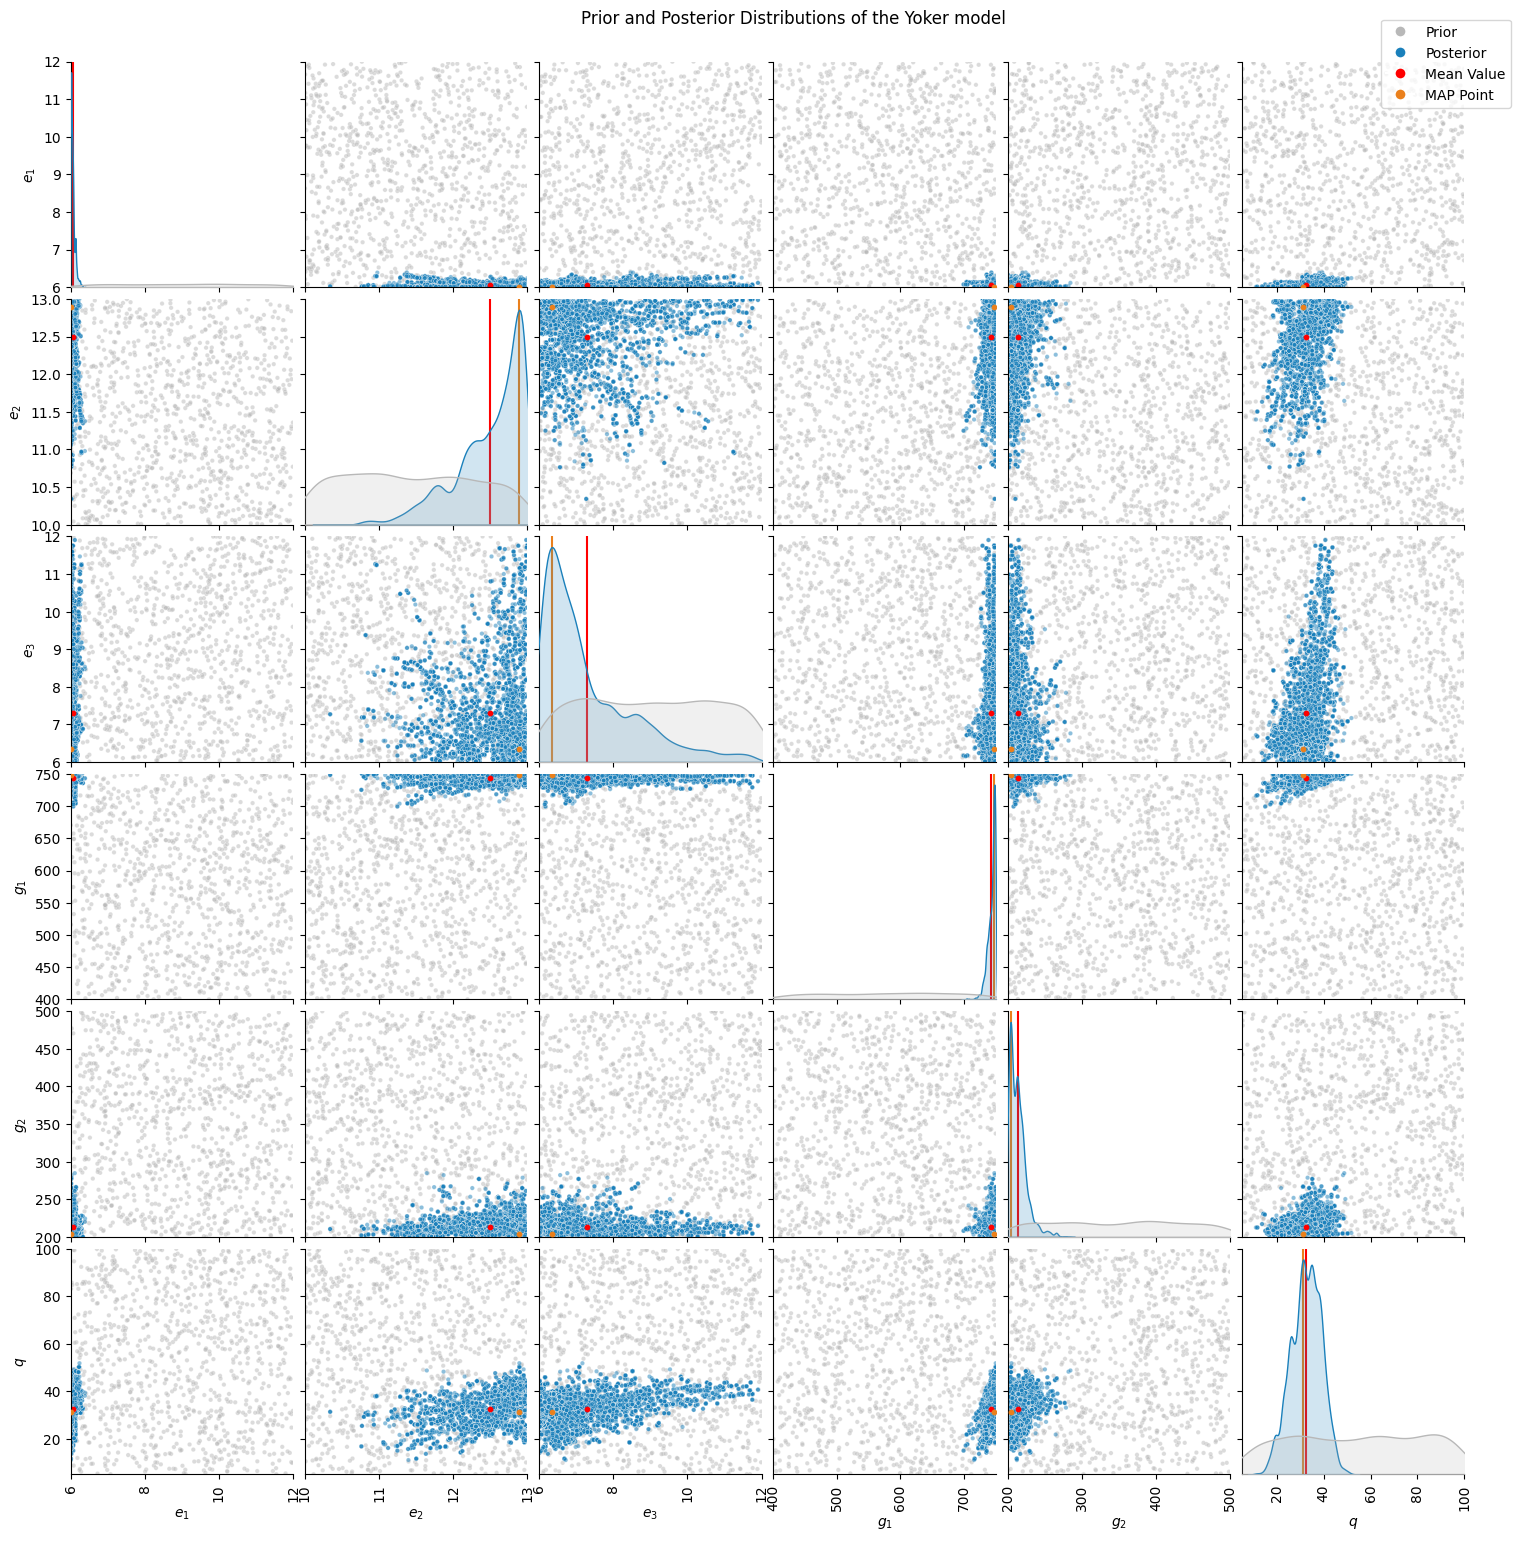

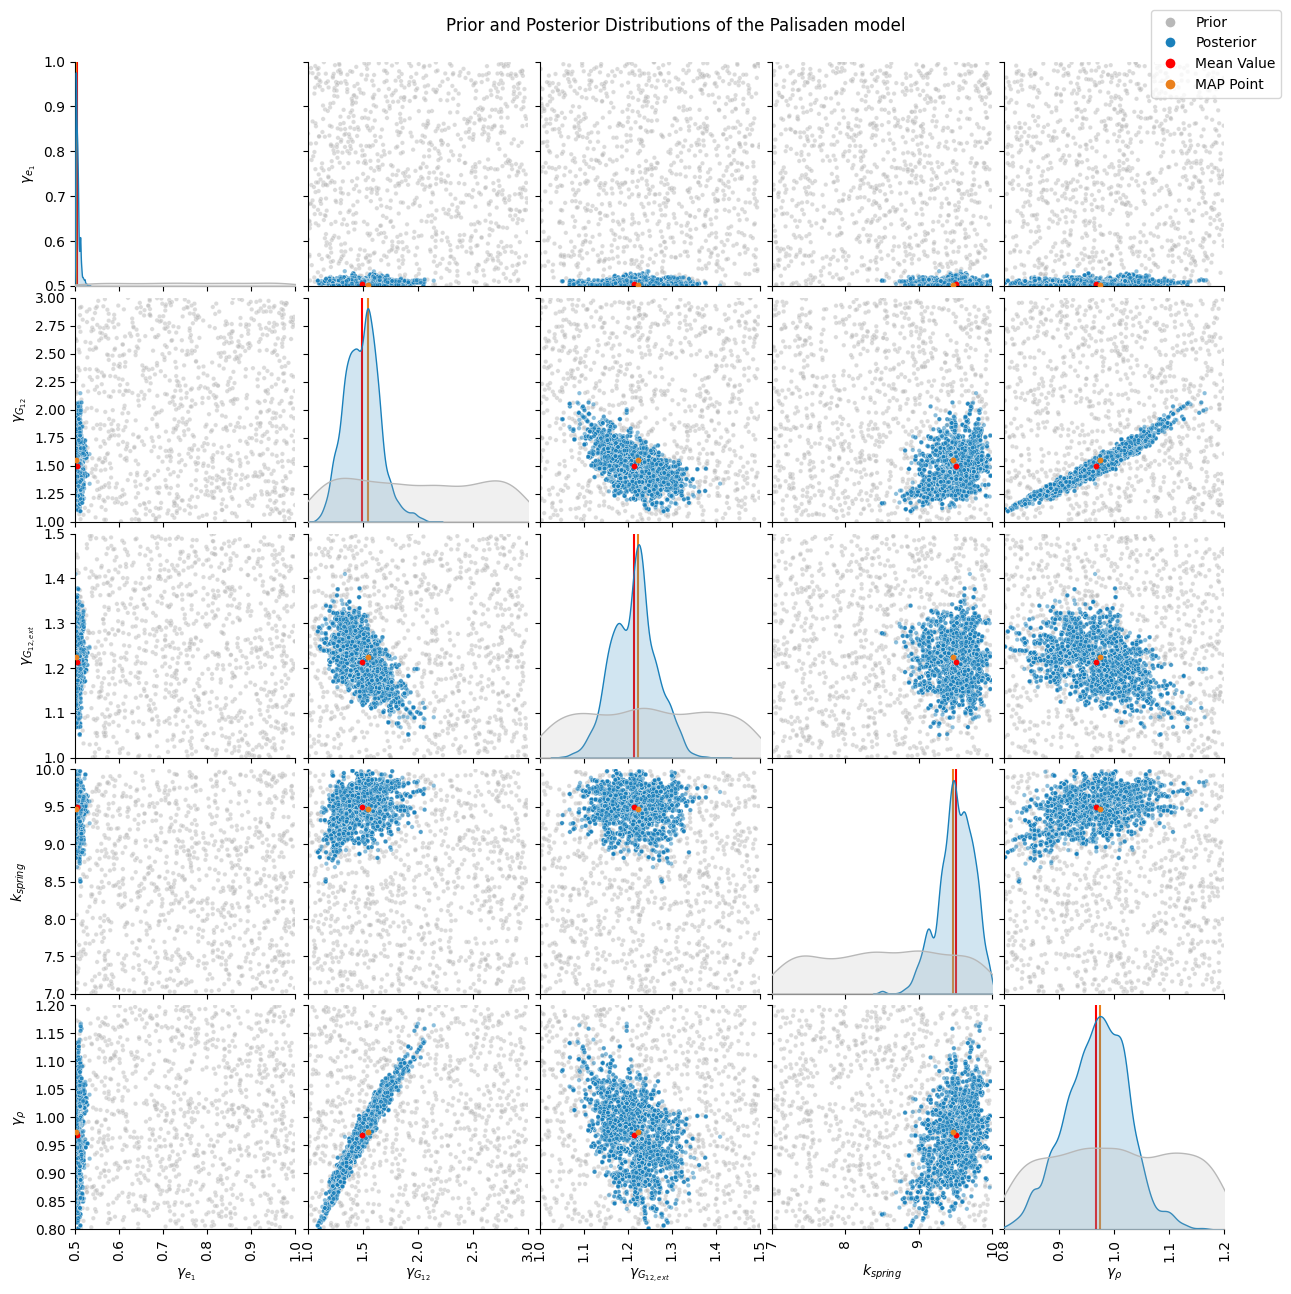

In [6]:
figs = dt.plot_multimodel_MCMC(j, map_point=True, model_names=['Yoker', 'Palisaden'], formatted_param_names=[["$e_{1}$", "$e_{2}$", "$e_{3}$", "$g_{1}$", "$g_{2}$", '$q$'], ["$γ_{e_{1}}$", "$γ_{G_{12}}$", "$γ_{G_{12,ext}}$", "$k_{spring}$", "$γ_{ρ}$"]])

In [7]:
model_index = 0
map_point, mean, variance, posterior_samples = j.get_data_of_model(model_index)

In [8]:
map_point

,e1,e2,e3,g1,g2,q
0,6.013878,12.891355,6.357414,747.692114,204.26375,31.102184


In [9]:
mean

,e1,e2,e3,g1,g2,q
0,6.058966,12.495239,7.304753,743.057983,213.768393,32.372627


In [10]:
variance

,e1,e2,e3,g1,g2,q
0,9.001063,11.638389,9.523842,575.239527,350.923917,53.368418


In [11]:
posterior_samples

,e1,e2,e3,g1,g2,q
0,6.030524,12.912212,6.223592,735.176445,219.501586,31.378190
1,6.125657,12.672177,8.772338,746.293789,209.693009,37.188080
2,6.037476,12.277614,6.205528,749.317590,200.372632,22.802942
3,6.077342,12.966134,6.533087,749.653130,221.774791,39.280342
4,6.037417,12.741961,6.326827,748.826857,212.525860,31.525060
...,...,...,...,...,...,...
6395,6.006790,12.625746,7.059110,736.623836,202.702125,31.231634
6396,6.033851,12.604711,10.412557,748.921255,222.357017,38.310526
6397,6.017933,12.658019,6.832710,733.430943,217.953548,30.757532
6398,6.058320,12.960517,6.155612,748.773944,233.695402,35.376868
